In [ ]:
pip install langchain_classic


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 35.2 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.18
    Uninstalling langchain-core-1.2.18:
      Successfully uninstalled langchain-core-1.2.18


In [ ]:
pip install langchain_core

In [ ]:
!pip install langchain-openai

In [ ]:
from google.colab import userdata
import os

# Colab Secrets에서 'OPENAI_API_KEY'를 가져옵니다.
try:
    api_key = userdata.get('OPENAI_API_KEY')
    os.environ['OPENAI_API_KEY'] = api_key
    print(f'Successfully loaded API key: {api_key[:10]}...')
except Exception as e:
    print('Colab Secrets에서 OPENAI_API_KEY를 찾을 수 없습니다. 왼쪽 열쇠 아이콘에서 설정을 확인해주세요.')

Successfully loaded API key: sk-proj-__...


In [ ]:
import os
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
embedding_model = OpenAIEmbeddings(model = 'text-embedding-3-small') # 1536차원으로 임베딩

In [ ]:
test_emb = embedding_model.embed_query("Hello")
test_emb[:5], len(test_emb)

([0.019266590476036072,
  -0.06451208889484406,
  -0.0016673645004630089,
  0.07812134176492691,
  0.021627109497785568],
 1536)

## 임베딩 캐싱 심화

In [ ]:
from langchain_classic.embeddings import CacheBackedEmbeddings # 내부적으로 InMemoryByteStore에 저장
from langchain_core.stores import InMemoryByteStore

### 💡 CacheBackedEmbeddings 주석 상세 설명

`CacheBackedEmbeddings`의 동작 방식과 주석 내용에 대한 상세 설명입니다:

1.  **고정된 내부 저장소가 아님**: `CacheBackedEmbeddings` 자체가 내부에 `InMemoryByteStore`를 고정적으로 가지고 있는 것은 아닙니다. 대신, 사용자가 어떤 `ByteStore`를 인자로 넘겨주느냐에 따라 저장 위치가 결정됩니다.
2.  **메모리 저장**: 현재 코드처럼 `InMemoryByteStore()`를 생성해서 전달한다면, 내부적으로 메모리(InMemory)에 저장하는 것이 맞습니다.
3.  **확장성**: 만약 `LocalFileStore`를 사용하면 로컬 파일에, `RedisStore`를 사용하면 레디스에 저장할 수도 있습니다.

**결론**: 주석을 더 정확하게 수정한다면 **"전달받은 ByteStore(예: InMemoryByteStore)를 사용하여 임베딩을 캐싱합니다"** 정도가 가장 적당합니다.

In [ ]:
store = InMemoryByteStore()
cached_embeddings = CacheBackedEmbeddings.from_bytes_store(
    embedding_model, store, namespace="embedding-cache"
) # store에 저장하세요, namespace는 "embedding-cache"로 지정하겠습니다. 라는 의미

/usr/local/lib/python3.12/dist-packages/langchain_classic/embeddings/cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_encoder()


### 🚀 코드내용 정리

1.  **`store = InMemoryByteStore()`**
    *   임베딩(계산 결과)을 적어둘 **저장 공간**을 마련한 것 (메모리 사용)
2.  **`embedding_model`**
    *   실제로 계산을 수행하여 **텍스트를 숫자로 변환하는 모델** (비용과 시간 발생)
3.  **`CacheBackedEmbeddings.from_bytes_store(...)`**
    *   모델과 저장소를 연결하여, **한 번 계산한 것은 저장소에서 바로 꺼내 쓰도록** 설정한 것
4.  **`namespace="embedding-cache"`**
    *   저장소 내에서 다른 데이터와 섞이지 않도록 붙인 **데이터 식별용 이름표**

In [ ]:
texts = ["인공지능이 계속 발전하고 있습니다.", "Langchain으로 RAG를 구현합시다."]
vecs1 = cached_embeddings.embed_documents(texts)

In [ ]:
import time
start = time.time()
texts = ["오늘 점심에는 라면을 먹었습니다.", "내일 저녁에는 햄버거를 먹을겁니다."]

vecs1 = cached_embeddings.embed_documents(texts)
t1 = time.time() - start
print(f"1차 call, {t1}초 (임베딩 시간)")

start = time.time()
vecs2 = cached_embeddings.embed_documents(texts)
t2 = time.time() - start
print(f"2차 call, {t2}초 (캐시 이용한 시간)")

1차 call, 0.0031828880310058594초 (임베딩 시간)
2차 call, 0.0027666091918945312초 (캐시 이용한 시간)


In [ ]:
long_text = """
인공지능(AI)은 컴퓨터 과학의 한 분야로, 인간의 학습능력, 추론능력, 지각능력을 인공적으로 구현하려는 기술입니다.
최근 대규모 언어 모델(LLM)의 발전으로 AI 기술은 급격한 변화를 겪고 있습니다. GPT, Claude, Gemini 등의 모델이 등장하며 자연어 처리 분야에서 혁신적인 성과를 보여주고 있습니다.
LangChain은 이러한 LLM을 활용한 애플리케이션 개발을 돕는 프레임워크입니다. 문서 로딩, 텍스트 분할, 임베딩, 벡터 검색 등의 기능을 제공하며, RAG(Retrieval-Augmented Generation) 시스템 구축에 특히 유용합니다.
RAG는 외부 지식을 LLM에 제공하여 답변의 정확성을 높이는 기술입니다. 문서를 청크로 나누고, 벡터 데이터베이스에 저장한 후, 질문과 관련된 청크를 검색하여 LLM에 전달합니다."""

In [ ]:
import tiktoken

def count_tokens(text, model = 'gpt-4o-mini'):
  enc = tiktoken.encoding_for_model(model)
  return len(enc.encode(text))

count_tokens(long_text)

216

In [ ]:
# 실습

def process_documents(docs, embedding_model, batch_size = 5):
  # 요구사항: docs를 batch_size별로 실행, 11개라면 5, 5, 1개 실행..
    # 중간에 배치가 끝날때 마다 실행 시간, 처리 토큰을 출력하는 함수
    # 모든 문서가 완료되었을 때 소요 시간과 전체 처리 토큰을 출력

  all_vectors = []
  total_tokens = 0
  start = time.time()

  # 아래 루프문 안에서 count_tokens() 사용
  for i in range(0, len(docs), batch_size): # docs(문서들)의 전체 개수에서 batch_size만큼 건너뛰라
    batch = docs[i:i+batch_size] # docs 리스트에서 0~5, 5~10, ... 등을 batch로 모음
    batch_tokens = sum(count_tokens(d) for d in batch) # ???: batch에 있는 하나의 요소(문서)의 토큰을 계산하고
                                                      #  batch 전체의 토큰 수 계산
    total_tokens += batch_tokens # batch 전체의 토큰

    vectors = embedding_model.embed_documents(batch)
    all_vectors.extend(vectors)

    progress = min(i+batch_size, len(docs)) # 전체 문서 개수에서 어느정도까지
    print(f"Processed {progress}/{len(docs)} batch {i//batch_size + 1} progress ({batch_tokens} tokens)")

  elapsed = time.time() - start

  print(f"completed, {len(docs)} documents, {total_tokens} tokens completed.")
  print(f"{elapsed} seconds")



 # return all_vectors # [코드 작성법] 항상 인자, 반환값을 먼저 설정하고, 로직을 설정

In [ ]:
docs = [f"doc {i}: 테스트 문서입니다." for i in range(20)]
vectors = process_documents(docs, cached_embeddings, batch_size = 5)

Processed 5/20 batch 1 progress (45 tokens)
Processed 10/20 batch 2 progress (45 tokens)
Processed 15/20 batch 3 progress (45 tokens)
Processed 20/20 batch 4 progress (45 tokens)
completed, 20 documents, 180 tokens completed.
0.04708385467529297 seconds


In [ ]:
for i in range(0, 10):
  print(i)

0
1
2
3
4
5
6
7
8
9


In [ ]:
for i in range(0, 10, 2):
  print(i)

0
2
4
6
8


In [ ]:
a = [1,2,3,4,5]
a.append(6)
a

[1, 2, 3, 4, 5, 6]

In [ ]:
a = [1,2,3,4,5]
a.append([6])
a

[1, 2, 3, 4, 5, [6]]

In [ ]:
# 바로 위 셀의 문제를 방지하기 위해(리스트의 차원을 유지하려면) extend 사용

a = [1,2,3,4,5]
a.extend([1,2,3])
a

[1, 2, 3, 4, 5, 1, 2, 3]

## 코사인 유사도와 임베딩 시각화

### 코사인유사도

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# 대부분은 벡터로 존재하게 됨, 벡터들의 사잇각, align, 비슷한 방향을 보고있는지 등.
# 코사인 함수를 이용하여 유사도를 계산하는 것이 코사인 유사도

In [ ]:
pairs = [
    ("오늘 날씨가 좋다", "오늘은 화창한 날이다"),
    ("오늘 날씨가 좋다", "날씨가 나쁘다"),
    ("파이썬 프로그래밍", "python programming"),
    ("인공지능 기술", "맛있는 김치찌개"),
    ("서울은 한국의 수도입니다", "seoul is the capital of Korea")
]

# cosine_similarity 함수 안에는 벡터만 들어갈 수 있음

In [ ]:
embs = embedding_model.embed_documents([text_a, text_b])
len(embs)

2

In [ ]:
embs[0][:5]

[-0.0024127960205078125,
 -0.045379638671875,
 0.0247650146484375,
 0.019500732421875,
 0.019287109375]

In [ ]:
for text_a, text_b in pairs: # 튜플 (a, b)들을 하나씩 임베딩 할 것
  embs = embedding_model.embed_documents([text_a, text_b])
  sim = cosine_similarity([embs[0]], [embs[1]])[0][0]

  print(f"similarity: {sim}, {text_a}, {text_b}")

similarity: 0.6274082618609262, 오늘 날씨가 좋다, 오늘은 화창한 날이다
similarity: 0.5242300122635414, 오늘 날씨가 좋다, 날씨가 나쁘다
similarity: 0.3860752634384818, 파이썬 프로그래밍, python programming
similarity: 0.1490592988406505, 인공지능 기술, 맛있는 김치찌개
similarity: 0.4997451188330585, 서울은 한국의 수도입니다, seoul is the capital of Korea


### 🔍 cosine_similarity 입력 형태와 결과의 차이

`sklearn.metrics.pairwise.cosine_similarity` 함수는 입력을 받을 때 **2차원 배열(행렬, Matrix)** 형태를 기대하며, 입력 방식에 따라 결과 구조가 달라집니다.

#### 1. 대괄호 `[embs[0]]`를 사용하는 이유 (차원 맞추기)
- **행렬 형태 요구**: 이 함수는 여러 벡터 간의 유사도를 한꺼번에 계산하도록 설계되어 `(샘플 수, 특징 수)` 형태의 구조가 필요합니다.
- **차원 맞추기**: `embs[0]`은 이미 숫자들이 담긴 1차원 리스트(벡터)입니다. 이를 그대로 넣으면 함수는 이를 행렬로 인식하지 못해 오류가 발생할 수 있습니다.
- **해결 방법**: `embs[0]`은 1차원 리스트이므로, `[embs[0]]`으로 감싸 **'1행짜리 행렬'**로 만들어 줍니다.

#### 2. `([embs[0]], [embs[1]])` vs `([embs[0], embs[1]])` 차이

*   **`cosine_similarity([embs[0]], [embs[1]])`** (현재 코드 방식)
    *   **의미**: 두 개의 서로 다른 행렬(A와 B)을 비교합니다.
    *   **결과**: `[[유사도]]` 형태의 1x1 행렬이 반환됩니다. 특정 두 대상의 수치만 깔끔하게 얻고 싶을 때 편리합니다.

*   **`cosine_similarity([embs[0], embs[1]])`**
    *   **의미**: 하나의 행렬 내에 있는 모든 벡터들끼리 **자기 자신을 포함해 서로서로(Pairwise)** 비교합니다.
    *   **결과**: 다음과 같은 **2x2 행렬**이 반환됩니다.
        *   `[0,0]`: A와 A의 유사도 (1.0)
        *   `[0,1]`: A와 B의 유사도 (우리가 원하는 값)
        *   `[1,0]`: B와 A의 유사도 (A와 B와 같음)
        *   `[1,1]`: B와 B의 유사도 (1.0)

**요약**: 단일 벡터라도 2차원 리스트 형태로 전달해야 하며, 단순히 두 값의 유사도만 필요할 때는 각각 별도의 인자로 전달하는 것이 결과 처리에 더 용이합니다.

In [ ]:
sentence = "AI 챗봇 개발하고 싶어요"
corpus = [
    "LangChain은 LLM 앱 개발 프레임워크입니다",
    "RAG는 검색 증강 생성 기술입니다",
    "벡터 데이터베이스는 임베딩을 저장합니다",
    "파인튜닝은 모델을 특정 데이터에 맞게 조정합니다",
    "프롬프트 엔지니어링은 AI에게 좋은 지시를 작성하는 기술입니다",
    "LangChain으로 챗봇 만들기",
    "React vs Vue 성능 비교",
    "GPT API 활용 가이드",
]
def find_most_similar(sentence, corpus):
  # vectorize 한 뒤,
  # query와의 cosine-similarity를 계산 해서
  # 가장 유사한 문장을 반환하도록 하는 함수

  all_vectors = []

  query_vector = embedding_model.embed_query(sentence)
  print("query_vector sample:", query_vector[:5])
  all_vectors.append(query_vector)
  embs_corpus = embedding_model.embed_documents(corpus)
  print("len(embs_corpus):", len(embs_corpus))
  print("embs_corpus sample:", embs_corpus[0][:5])
  all_vectors.extend(embs_corpus)
  print(f"len(all_vectors): {len(all_vectors)}")

  sim = cosine_similarity(all_vectors) # 아마 all_vector의 shape은 (9, 1536)인듯,
                                       # sim을 구하게 되면 9x9 행렬?
  #print(sim)
  print("similarity sample:", sim[0])
  best_corpus = corpus[sim[0].argmax()]

  return best_corpus

  # 유사도를 rank (sorted()) 하여 순서대로 top_k개만 뽑거나 할 수 있음


In [ ]:
find_most_similar(sentence, corpus)

query_vector sample: [-0.046173095703125, -0.03619384765625, -0.00891876220703125, -0.01084136962890625, 0.02081298828125]
len(embs_corpus): 8
embs_corpus sample: [0.0023562868591398, 0.03278312087059021, 0.02795800007879734, -0.02330602891743183, 0.04148681089282036]
len(all_vectors): 9
similarity sample: [1.         0.31333065 0.23925812 0.18545867 0.20580203 0.26394355
 0.59326096 0.14958866 0.21368002]


'LangChain은 LLM 앱 개발 프레임워크입니다'

### 📊 `embed_query` vs `embed_documents` 비교

| 메서드 | 입력 형태 (Input) | 출력 형태 (Output) | 주요 용도 |
| :--- | :--- | :--- | :--- |
| **`embed_query`** | `"문자열"` (단일 문장) | `[0.1, 0.2, ...]` (1차원 리스트) | 질문(Query) 하나를 벡터화 |
| **`embed_documents`** | `["문장1", "문장2"]` (문자열 리스트) | `[[0.1, ...], [0.3, ...]]` (2차원 리스트) | 여러 문서(Documents)를 한꺼번에 벡터화 |

#### 💡 예시 코드로 보기

```python
# 1. embed_query: 문장 하나를 넣고, 숫자 리스트 하나를 받음
query_vector = embedding_model.embed_query("오늘 날씨 어때?")
# 결과: [0.12, -0.05, 0.23, ...]

# 2. embed_documents: 문장 리스트를 넣고, 숫자 리스트의 리스트를 받음
doc_vectors = embedding_model.embed_documents(["날씨가 좋습니다", "비가 내립니다"])
# 결과: [[0.1, 0.2, ...], [0.3, 0.4, ...]]
```

### 임베딩 시각화

In [ ]:
# 시각화를 위해서는 벡터의 차원(예:1536차원)을 압축하여야 함(2~3차원 등 저차원으로)
from sklearn.decomposition import PCA # 데이터가 구성되는 공간을 수학적으로 가장 잘 설명하는 축을 찾아내는 방법
from sklearn.manifold import TSNE # t 분포를 이용하여 가까운 점들끼린 가깝게, 멀리는 멀리 등등..


In [ ]:
topic_sentences = {
    "tech": [
        "인공지능이 산업을 혁신하고 있다",
        "클라우드 컴퓨팅이 IT를 변화시킨다",
        "블록체인이 금융을 바꾸고 있다",
        "5G가 통신을 혁신한다",
    ],
    "sports": [
        "축구 경기에서 역전골이 터졌다",
        "올림픽에서 금메달을 획득했다",
        "야구 시즌이 개막했다",
        "마라톤 대회에서 신기록을 세웠다",
    ],
    "food": [
        "이 레스토랑의 파스타가 맛있었다",
        "한국 김치는 발효 식품이다",
        "새로운 카페에서 커피를 마셨다",
        "맛집 탐방이 요즘 인기다",
    ],
    "finance": [
        "주식 시장이 크게 하락했다",
        "비트코인 가격이 급등했다",
        "금리 인상이 예상된다",
        "환율이 급변하고 있다",
    ],
}

In [ ]:
all_texts = []
all_labels = []
for topic, sents in topic_sentences.items():
  all_texts.extend(sents)
  all_labels.extend([topic] * len(sents))

In [ ]:
all_labels

['tech',
 'tech',
 'tech',
 'tech',
 'sports',
 'sports',
 'sports',
 'sports',
 'food',
 'food',
 'food',
 'food',
 'finance',
 'finance',
 'finance',
 'finance']

In [ ]:
all_embs = embedding_model.embed_documents(all_texts)

In [ ]:
import numpy as np
emb_matrix = np.array(all_embs)

In [ ]:
len(all_embs), len(all_embs[0])

(16, 1536)

In [ ]:
emb_matrix

array([[ 5.54690044e-03,  8.62676557e-03,  2.40313299e-02, ...,
        -1.49069671e-02, -1.51374331e-03,  1.43098505e-02],
       [-1.26992241e-02,  8.85213818e-03,  3.22255157e-02, ...,
        -5.47043495e-02,  8.00698716e-03, -2.30495855e-02],
       [-1.30307637e-02,  4.10045832e-02, -1.59357768e-02, ...,
        -1.86944958e-02,  1.56013872e-02,  3.85071081e-03],
       ...,
       [-2.74965838e-02, -3.58713605e-02, -2.80357320e-02, ...,
         8.50057788e-03, -3.15731922e-05,  2.30396204e-02],
       [ 3.86716537e-02,  2.90220622e-02, -2.79716011e-02, ...,
        -9.55798198e-03,  1.01442859e-02,  7.99297646e-04],
       [-1.82036255e-02,  4.36253659e-03,  6.38819486e-03, ...,
        -1.43488683e-02, -2.42205411e-02, -1.98853035e-02]])

In [ ]:
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(emb_matrix) # 좌표 형태로 나옴
coords_2d # 기존에는 (16, 1536)이었는데, 이제는 2차원 16개로 변환됨

array([[ 0.35265032,  0.18297995],
       [ 0.39713451,  0.26939299],
       [-0.08283749,  0.26359619],
       [ 0.36643127,  0.24585181],
       [-0.44106505, -0.03668295],
       [-0.51104772,  0.09780062],
       [-0.29244485,  0.04156492],
       [-0.39711868, -0.229949  ],
       [ 0.04546551, -0.55698917],
       [ 0.23999932, -0.31688207],
       [ 0.38303358, -0.39508409],
       [ 0.12778883, -0.43266234],
       [-0.04058968, -0.09594126],
       [ 0.08664264,  0.31738034],
       [-0.38348894,  0.19704015],
       [ 0.14944644,  0.44858391]])

In [ ]:
colors = {"tech": "#FF6B6B", "sports": "#4ECDC4", "food": "#FFD93D", "finance": "#6C5CE7"}

In [ ]:
pip install matplotlib

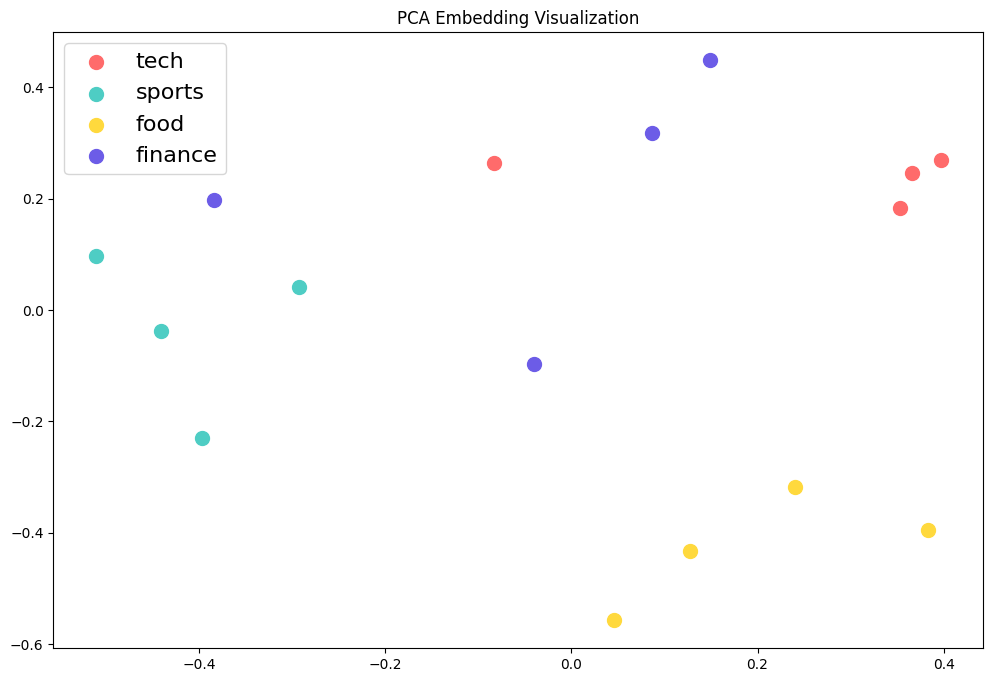

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
for topic in topic_sentences:
    mask = [l == topic for l in all_labels]
    # coords_2d는 numpy array이므로 마스킹이 가능하도록 변환 확인
    x = coords_2d[mask, 0]
    y = coords_2d[mask, 1]
    ax.scatter(x, y, c=colors[topic], label=topic, s=100)

ax.legend(fontsize=16)
ax.set_title('PCA Embedding Visualization')
plt.show()

In [ ]:
tsne = TSNE(n_components = 2, random_state = 24, perplexity=5) # perplexity는 얼만큼 주위에 있는 것을 한 묶음으로 볼것이냐.

In [ ]:
coords_2d = tsne.fit_transform(emb_matrix)

In [ ]:
colors = {"tech": "#FF6B6B", "sports": "#4ECDC4", "food": "#FFD93D", "finance": "#6C5CE7"}

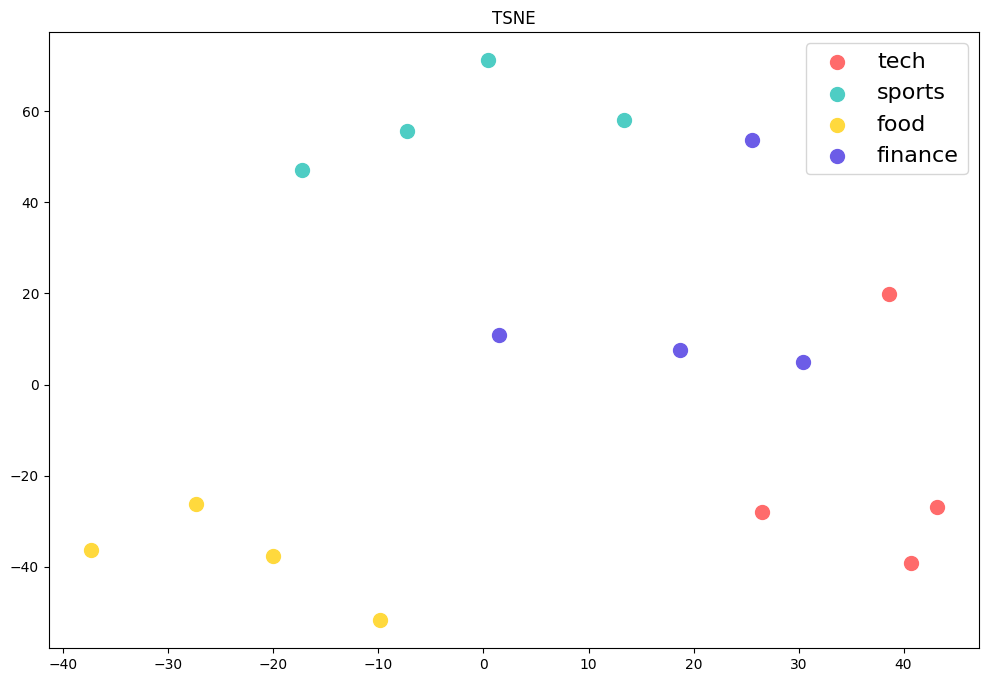

In [ ]:

fig, ax = plt.subplots(figsize=(12, 8))
for topic in topic_sentences:
    mask = [l == topic for l in all_labels]
    # coords_2d는 numpy array이므로 마스킹이 가능하도록 변환 확인
    x = coords_2d[mask, 0]
    y = coords_2d[mask, 1]
    ax.scatter(x, y, c=colors[topic], label=topic, s=100)

ax.legend(fontsize=16)
ax.set_title('TSNE') # TSNE는 랜덤성이 있고, 고정하는 값이 있는데 random_state = 값 을 이용해 고정
plt.show()

## FAISS 벡터 데이터베이스

### 벡터검색

### 🚀 FAISS (Facebook AI Similarity Search) 개요

**FAISS**는 Meta(Facebook) AI 리서치 팀에서 개발한 **고성능 벡터 검색 라이브러리**입니다.

1.  **목적**: 수백만 개 이상의 고차원 벡터들 사이에서 질문(Query)과 가장 유사한 벡터를 **매우 빠르게** 찾아내기 위해 사용합니다.
2.  **핵심 특징**:
    *   **속도와 효율성**: 일반적인 무차별 대입(Brute-force) 검색보다 훨씬 빠른 인덱싱 알고리즘을 제공합니다.
    *   **다양한 인덱스**: 데이터 규모에 따라 Flat(정확), IVF(클러스터링), HNSW(그래프 기반) 등 다양한 검색 방식을 선택할 수 있습니다.
    *   **GPU 지원**: CPU뿐만 아니라 GPU를 활용한 초고속 연산이 가능합니다.
3.  **RAG에서의 역할**: LangChain과 같은 프레임워크에서 **로컬 벡터 데이터베이스** 역할을 하며, 문서를 임베딩하여 저장하고 질문과 관련된 문서를 검색하는 데 핵심적으로 사용됩니다.

In [ ]:
# 벡터검색을 빠르게 하기 위한 라이브러리
# FAISS (Facebook AI Similarity Search)

In [ ]:
pip install langchain_community

In [ ]:
from langchain_community.vectorstores import FAISS

In [ ]:
faq_docs = [
    "LangChain은 LLM 애플리케이션 개발을 위한 프레임워크입니다.",
    "RAG는 외부 문서를 검색하여 LLM 답변 정확도를 높이는 기술입니다.",
    "벡터 데이터베이스는 임베딩 벡터를 효율적으로 저장하고 검색합니다.",
    "프롬프트 엔지니어링은 AI에게 효과적인 지시를 작성하는 기술입니다.",
    "파인튜닝은 사전학습된 모델을 특정 도메인 데이터로 추가 학습시킵니다.",
    "토큰은 LLM이 텍스트를 처리하는 기본 단위입니다.",
    "임베딩은 텍스트를 수치 벡터로 변환하는 기술입니다.",
    "LCEL은 LangChain의 체인 구성을 위한 표현식 언어입니다.",
    "에이전트는 LLM이 도구를 사용해서 자율적으로 작업하는 시스템입니다.",
    "Gradio는 ML 모델을 위한 간단한 웹 인터페이스를 만드는 라이브러리입니다.",
]

In [ ]:
pip install faiss-cpu

In [ ]:
vectorstore = FAISS.from_texts(faq_docs, embedding_model) # FAISS를 쓰기위해서 임베딩 모델을 쓰긴 해야함

# FAISS는 벡터를 저장하고 검색하는 '저장소' 역할, 텍스트 그 자체를 이해하지는 못함
# 따라서 텍스트(faq_docs)를 FAISS에 넣기 위해서는 텍스트를 숫자 형태(벡터)로 변환해줄 임베딩 모델(embedding_model)이 필요

In [ ]:
queries = [
    "RAG가 뭐예요?", "AI 챗봇을 어떻게 만드나요?", "토큰 비용을 줄이려면?"
]

for query in queries:
  results = vectorstore.similarity_search_with_score(query, k=3)
  # print(results)
  for doc, score in results:
    print(f"[{score}] {doc.page_content}")
  print("==="*4)

[0.9830997586250305] RAG는 외부 문서를 검색하여 LLM 답변 정확도를 높이는 기술입니다.
[1.511527180671692] 토큰은 LLM이 텍스트를 처리하는 기본 단위입니다.
[1.5696005821228027] Gradio는 ML 모델을 위한 간단한 웹 인터페이스를 만드는 라이브러리입니다.
[1.4891736507415771] 프롬프트 엔지니어링은 AI에게 효과적인 지시를 작성하는 기술입니다.
[1.5330579280853271] Gradio는 ML 모델을 위한 간단한 웹 인터페이스를 만드는 라이브러리입니다.
[1.582426905632019] LangChain은 LLM 애플리케이션 개발을 위한 프레임워크입니다.
[1.2465994358062744] 토큰은 LLM이 텍스트를 처리하는 기본 단위입니다.
[1.3880542516708374] 임베딩은 텍스트를 수치 벡터로 변환하는 기술입니다.
[1.4397886991500854] 벡터 데이터베이스는 임베딩 벡터를 효율적으로 저장하고 검색합니다.


In [ ]:
# 의존성 관련해서는 테스트 코드를 작성해서, 그걸 다 통과해야,,, 버전들 확정하는 방식

In [ ]:
from langchain_core.documents import Document

In [ ]:
# 내용 뿐만 아닌 메타데이터를 함께 넣기 위함(카테고리, 저자, 제조사 등등)
docs_with_meta = [
    Document(page_content = 'Langchain은 LLM앱 개발 프레임워크입니다', metadata = {'category' : 'framework', 'level' : 'beginner'}),
    Document(page_content = 'RAG는 검색증강생성 기술입니다', metadata = {'category' : 'technique', 'level' : 'intermediate'}),
    Document(page_content = 'FAISS는 벡터 유사도 검색 라이브러리입니다', metadata = {'category' : 'tool', 'level' : 'intermediate'}),
    Document(page_content = '프롬프트 엔지니어링은 AI 지시를 작성하는 기술입니다', metadata = {'category' : 'technique', 'level' : 'beginner'}),
    Document(page_content = '에이전트는 LLM이 도구를 자율적으로 사용하는 시스템입니다', metadata = {'category' : 'technique', 'level' : 'advanced'}),
]

vs_meta = FAISS.from_documents(docs_with_meta, embedding_model)
vs_meta

In [ ]:
results = vs_meta.similarity_search('AI 개발 도구', k=3)
results

[Document(id='e83714e0-4534-4878-bf24-8a837e7f9bbf', metadata={'category': 'technique', 'level': 'beginner'}, page_content='프롬프트 엔지니어링은 AI 지시를 작성하는 기술입니다'),
 Document(id='067950e4-5913-487a-a646-2d393d0fbed1', metadata={'category': 'technique', 'level': 'advanced'}, page_content='에이전트는 LLM이 도구를 자율적으로 사용하는 시스템입니다'),
 Document(id='15b2c7f9-737a-4a44-90ee-0a9daae13f87', metadata={'category': 'framework', 'level': 'beginner'}, page_content='Langchain은 LLM앱 개발 프레임워크입니다')]

In [ ]:
for doc in results:
  print(f"[{doc.metadata['category']}, {doc.metadata['level']}, {doc.page_content}]")

[technique, beginner, 프롬프트 엔지니어링은 AI 지시를 작성하는 기술입니다]
[technique, advanced, 에이전트는 LLM이 도구를 자율적으로 사용하는 시스템입니다]
[framework, beginner, Langchain은 LLM앱 개발 프레임워크입니다]


In [ ]:
embedding_model = OpenAIEmbeddings(model = 'text-embedding-3-small')

In [ ]:
# '프롬프트 엔지니어링은 AI 지시를 작성하는 기술입니다' -> 토큰화 [3, 109, 1334, 14562,...] -> 1536 차원 벡터

In [ ]:
multilingual = [
    ('인공지능이 세상을 바꾸고 있다.', '한국어'),
    ('Artificial Intelligence is changing the world.', '영어'),
    ('나는 학교에 갑니다.', '한국어'),
    ('I go home', '영어')
]

texts = [t for t, l in multilingual]
langs = [l for t, l in multilingual]


In [ ]:
langs

['한국어', '영어', '한국어', '영어']

In [ ]:
texts

['인공지능이 세상을 바꾸고 있다.',
 'Artificial Intelligence is changing the world.',
 '나는 학교에 갑니다.',
 'I go home']

In [ ]:
embs_multi = embedding_model.embed_documents(texts)

sim_matrix = cosine_similarity(embs_multi)

In [ ]:
sim_matrix

array([[1.        , 0.60055921, 0.11223823, 0.04819369],
       [0.60055921, 1.        , 0.00132704, 0.04020121],
       [0.11223823, 0.00132704, 1.        , 0.29481257],
       [0.04819369, 0.04020121, 0.29481257, 1.        ]])

#### 교차검색

In [ ]:
english_docs = [
    "LangChain is a framework for building LLM applications.",
    "RAG improves LLM accuracy by retrieving external documents.",
    "Vector databases store and search embedding vectors efficiently.",
    "Fine-tuning adapts a pre-trained model to specific data.",
    "Prompt engineering is the art of crafting effective instructions for AI.",
]

In [ ]:
# FAISS 이용해서

vs_en = FAISS.from_texts(english_docs, embedding_model)
korean_queries = [
    "RAG가 뭐예요?", "벡터 데이터베이스 설명해주세요", "프롬프트 엔지니어링은?"

]

for q in korean_queries:
  results = vs_en.similarity_search_with_score(q, k=3)
  for doc, score in results:
    print(f"[{score}] {doc.page_content}")
  print("==="*4)


[1.0950380563735962] RAG improves LLM accuracy by retrieving external documents.
[1.684887170791626] LangChain is a framework for building LLM applications.
[1.8270063400268555] Prompt engineering is the art of crafting effective instructions for AI.
[1.4565966129302979] Vector databases store and search embedding vectors efficiently.
[1.725653052330017] RAG improves LLM accuracy by retrieving external documents.
[1.781683087348938] Fine-tuning adapts a pre-trained model to specific data.
[1.5416090488433838] Prompt engineering is the art of crafting effective instructions for AI.
[1.7581967115402222] Vector databases store and search embedding vectors efficiently.
[1.771654486656189] Fine-tuning adapts a pre-trained model to specific data.


## 📝 오늘 학습 내용 총정리

### 1. 텍스트 임베딩 (Text Embedding)
- **개념**: 텍스트를 AI 모델이 이해할 수 있는 고정된 크기의 수치 벡터(예: 1536차원)로 변환하는 기술입니다.
- **메서드 구분**:
    - `embed_query`: 단일 질문용 (1차원 벡터 반환)
    - `embed_documents`: 여러 문서 뭉치용 (2차원 행렬 반환)

### 2. 임베딩 캐싱 (CacheBackedEmbeddings)
- **목적**: 동일한 텍스트에 대한 반복적인 임베딩 계산을 방지하여 API 비용과 시간을 절약합니다.
- **구성**: `InMemoryByteStore`와 같은 저장소와 임베딩 모델을 연결하여 사용합니다.

### 3. 코사인 유사도 (Cosine Similarity)
- **개념**: 두 벡터 사이의 각도를 측정하여 문장 간의 의미적 유사성을 계산합니다 (1.0에 가까울수록 유사).
- **특징**: 스케일러 연산을 위해 입력값을 2차원 배열 형태로 전달해야 합니다.

### 4. 벡터 시각화 (PCA & t-SNE)
- **차원 축소**: 1536차원과 같은 고차원 데이터를 2차원 평면으로 압축하여 시각적으로 확인합니다.
- **PCA**: 데이터의 분산을 최대한 보존하며 선형적으로 축소합니다.
- **t-SNE**: 데이터 간의 국소적 거리를 보존하여 군집화된 특징을 잘 보여줍니다.

### 5. 벡터 검색 (FAISS)
- **개념**: Meta에서 개발한 고성능 벡터 유사도 검색 라이브러리입니다.
- **활용**: 대량의 문서 중 질문과 가장 관련 있는 문서를 빠르게 찾아내는 RAG 시스템의 핵심 컴포넌트입니다.
- **메타데이터**: `Document` 객체를 사용하여 텍스트뿐만 아니라 카테고리, 레벨 등 부가 정보를 함께 저장하고 검색할 수 있습니다.

### 6. 다국어 및 교차 언어 검색
- **언어 횡단 검색**: 영어 문서를 한국어 질문으로 검색하는 것이 가능함을 확인했습니다. 이는 임베딩 모델이 언어와 상관없이 '의미'를 숫자 공간에 배치하기 때문입니다.